## **Mục tiêu:**

Xây dựng và đánh giá mô hình **ARIMA** nhằm dự báo biến động ngắn hạn của các tài sản tài chính.

Các mục tiêu chính bao gồm:

* **Xây dựng mô hình dự báo 24 giờ tới:**
  Sử dụng chuỗi **log return** để dự báo **24 bước thời gian tiếp theo (24h ahead forecast)** cho từng tài sản.

* **Đánh giá khả năng dự báo trên nhiều lớp tài sản:**
  So sánh hiệu quả của ARIMA giữa các nhóm nhằm xác định mức độ phù hợp của mô hình với từng cấu trúc thị trường.

* **Phân tích hành vi dự báo của mô hình:**
  Quan sát khả năng nhận diện **xu hướng (trend), quán tính (momentum), hồi quy trung bình (mean reversion)** hoặc đặc tính **random walk** trong dữ liệu tài chính.


In [23]:
%pip install --no-cache-dir pmdarima

Note: you may need to restart the kernel to use updated packages.


## Import các thư viện cần thiết

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from pathlib import Path
from datetime import timedelta
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pmdarima as pm # Cài đặt nếu chưa có: pip install pmdarima

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

In [25]:
file_path = max(
    Path("../data/snapshots").glob("market_snapshot_*.csv")
)
print("Latest snapshot:", file_path)
df = pd.read_csv(file_path)

if 'time_timestamp' in df.columns:
    df['datetime'] = pd.to_datetime(df['time_timestamp'], unit='s')
else:
    df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values(['symbol', 'datetime']).reset_index(drop=True)

print(f"Đã tải Snapshot: {df.shape[0]} dòng, {df['symbol'].nunique()} tài sản.")

Latest snapshot: ..\data\snapshots\market_snapshot_20260510_150719.csv
Đã tải Snapshot: 71158 dòng, 27 tài sản.


## **2. Feature Engineering & Chia tập dữ liệu**

Ở bước này, dữ liệu được chuyển đổi từ chuỗi giá gốc sang các biến đặc trưng phục vụ cho quá trình huấn luyện mô hình:

* **Tính toán Log Return:**
  Chuyển đổi chuỗi giá thành **tỷ suất sinh lợi logarit *(Log Return)*** nhằm loại bỏ xu hướng dài hạn và đưa dữ liệu về trạng thái **dừng *(Stationary)***.

* **Biến mục tiêu *(Target - $Y$)*:**

  * **`target_return`** – tỷ suất sinh lợi của nến kế tiếp *(T+1)*, đại diện cho giá trị mà mô hình cần dự báo.

* **Biến đầu vào *(Features - $X$)*:**
  Tạo các biến trễ *(Lag Features)* gồm **1h, 2h, 3h và 24h**, giúp mô hình học được **quán tính giá *(price momentum)* và phụ thuộc theo thời gian** của chuỗi dữ liệu.

**Chia tập dữ liệu:**
  Dữ liệu được chia theo **thứ tự thời gian** thành tập **Train** và **Test**, đảm bảo không xảy ra hiện tượng **rò rỉ dữ liệu *(data leakage)*** trong quá trình đánh giá mô hình.


In [26]:
df['log_return'] = np.log(df['close'] / df.groupby('symbol')['close'].shift(1))

df['target_return'] = df.groupby('symbol')['log_return'].shift(-1)

lags = [1, 2, 3, 24] 
for lag in lags:
    df[f'return_lag_{lag}'] = df.groupby('symbol')['log_return'].shift(lag)

df = df.dropna().reset_index(drop=True)

df['symbol_encoded'] = df['symbol'].astype('category').cat.codes


df['row_num'] = df.groupby('symbol').cumcount()
df['total_rows'] = df.groupby('symbol')['symbol'].transform('count')

train_df = df[df['row_num'] < df['total_rows'] * 0.8].copy()
test_df = df[df['row_num'] >= df['total_rows'] * 0.8].copy()

train_df.drop(columns=['row_num', 'total_rows'], inplace=True)
test_df.drop(columns=['row_num', 'total_rows'], inplace=True)
df.drop(columns=['row_num', 'total_rows'], inplace=True)

print(f"Train size: {len(train_df)} rows")
print(f"Test size:  {len(test_df)} rows")
print(f"Số lượng tài sản trong tập Test: {test_df['symbol'].nunique()}/30")

Train size: 56373 rows
Test size:  14083 rows
Số lượng tài sản trong tập Test: 27/30


## **3. Thiết lập Mô hình Cơ sở ARIMA**

Trong bước này, **Auto-ARIMA** được sử dụng làm mô hình dự báo cơ sở để đánh giá hiệu quả trên toàn bộ danh mục tài sản.


In [27]:
arima_results = []

print("Đang khởi động Auto-ARIMA cho các tài sản trên toàn bộ tập Test...")
start_time = time.time()

for sym in test_df['symbol'].unique():
    
    data_sym = test_df[test_df['symbol'] == sym]['log_return'].values
    split = int(len(data_sym) * 0.8)
    y_train_arima = data_sym[:split]
    y_test_arima = data_sym[split:]
    
    try:
        model = pm.auto_arima(
            y_train_arima,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            max_p=3,
            max_q=3
        )

        preds = model.predict(n_periods=len(y_test_arima))

        rmse = np.sqrt(mean_squared_error(y_test_arima, preds))
        mae = mean_absolute_error(y_test_arima, preds)
        
        arima_results.append({
            'symbol': sym,
            'ARIMA_RMSE': rmse,
            'ARIMA_MAE': mae
        })
        
        print(f"[+] {sym:<10} | RMSE: {rmse:.5f}")
        
    except Exception as e:
        print(f" Lỗi ARIMA tại {sym}: {e}")

df_baseline = pd.DataFrame(arima_results)
display(df_baseline)

Đang khởi động Auto-ARIMA cho các tài sản trên toàn bộ tập Test...
[+] AAPL       | RMSE: 0.00580
[+] ADA-USD    | RMSE: 0.00548
[+] AMZN       | RMSE: 0.00494
[+] AUDUSD=X   | RMSE: 0.00094
[+] AVAX-USD   | RMSE: 0.00532
[+] BNB-USD    | RMSE: 0.00329
[+] BTC-USD    | RMSE: 0.00317
[+] DOGE-USD   | RMSE: 0.00558
[+] ETH-USD    | RMSE: 0.00382
[+] EURUSD=X   | RMSE: 0.00066
[+] GBPUSD=X   | RMSE: 0.00070
[+] GC=F       | RMSE: 0.00266
[+] GOOGL      | RMSE: 0.00468
[+] LINK-USD   | RMSE: 0.00520
[+] META       | RMSE: 0.00784
[+] MSFT       | RMSE: 0.00641
[+] NVDA       | RMSE: 0.01067
[+] SI=F       | RMSE: 0.00548
[+] SOL-USD    | RMSE: 0.00458
[+] TSLA       | RMSE: 0.00991
[+] USDCAD=X   | RMSE: 0.00056
[+] USDCHF=X   | RMSE: 0.00075
[+] USDJPY=X   | RMSE: 0.00136
[+] XRP-USD    | RMSE: 0.00353
[+] ^DJI       | RMSE: 0.00292
[+] ^GSPC      | RMSE: 0.00268
[+] ^IXIC      | RMSE: 0.00354


,symbol,ARIMA_RMSE,ARIMA_MAE
0,AAPL,0.005797,0.003790
1,ADA-USD,0.005477,0.003840
2,AMZN,0.004941,0.003714
3,AUDUSD=X,0.000935,0.000681
4,AVAX-USD,0.005324,0.003877
5,BNB-USD,0.003290,0.002244
6,BTC-USD,0.003173,0.002089
7,DOGE-USD,0.005580,0.003593
8,ETH-USD,0.003821,0.002639
9,EURUSD=X,0.000661,0.000471


#### **Phân tích hiệu suất mô hình ARIMA**

Kết quả RMSE/MAE trên 27 tài sản cho thấy mức độ dễ dự báo giữa các thị trường khác nhau khá rõ:

* **Sai số thấp nhất:** Nhóm Forex (**EUR/USD, GBP/USD, USD/CAD**) có RMSE nhỏ nhất, phản ánh thanh khoản cao và biến động ổn định.

* **Sai số thấp – trung bình:** Nhóm **Index** như **S&P 500**, **Dow Jones** và **Gold Futures** cho kết quả khá tốt nhờ xu hướng ổn định và ít nhiễu.

* **Sai số trung bình:** Nhóm Crypto như **Bitcoin** và **Ethereum** có sai số cao hơn do biến động mạnh hơn.

* **Sai số cao nhất:** Nhóm Big Tech như **NVIDIA Corporation**, **Tesla, Inc.** và **Meta Platforms, Inc.** khó dự báo nhất, chủ yếu do các cú **gap giá** và ảnh hưởng từ tin tức doanh nghiệp.

##### **Kết luận**

ARIMA hoạt động tốt với các thị trường ổn định như Forex, Index, nhưng hiệu quả giảm rõ rệt với các tài sản có biến động phi tuyến như Crypto và Big Tech. Kết quả này sẽ được dùng làm **baseline** cho các mô hình tiếp theo.

## 4. Dự báo Tương lai

Sử dụng kiến trúc **Local ARIMA** để dự báo trực tiếp **Giá đóng cửa (Close Price)** cho 24 giờ tiếp theo của toàn bộ 30 tài sản.

In [28]:
forecast_horizon = 24 
all_forecasts = []

print(f"ĐANG KHỞI ĐỘNG HỆ THỐNG DỰ BÁO CHO {df['symbol'].nunique()} TÀI SẢN...")
start_time = time.time()

for sym in df['symbol'].unique():
    data_sym = df[df['symbol'] == sym].tail(1000)
    y_train = data_sym['close'].values
    
    try:
        model = pm.auto_arima(y_train, seasonal=False, stepwise=True, 
                              suppress_warnings=True, max_p=3, max_q=3)
        preds = model.predict(n_periods=forecast_horizon)
        last_dt = pd.to_datetime(data_sym['datetime'].iloc[-1])
        future_dates = [last_dt + timedelta(hours=i) for i in range(1, forecast_horizon + 1)]
        
        for i in range(forecast_horizon):
            all_forecasts.append({
                'symbol': sym,
                'datetime': future_dates[i],
                'predicted_close': round(preds[i], 4)
            })
        print(f"[+] {sym:<10} | Hoàn tất dự báo 24h tới.")
        
    except Exception as e:
        print(f" Lỗi dự báo tại {sym}: {e}")
df_forecast = pd.DataFrame(all_forecasts)

ĐANG KHỞI ĐỘNG HỆ THỐNG DỰ BÁO CHO 27 TÀI SẢN...
[+] AAPL       | Hoàn tất dự báo 24h tới.
[+] ADA-USD    | Hoàn tất dự báo 24h tới.
[+] AMZN       | Hoàn tất dự báo 24h tới.
[+] AUDUSD=X   | Hoàn tất dự báo 24h tới.
[+] AVAX-USD   | Hoàn tất dự báo 24h tới.
[+] BNB-USD    | Hoàn tất dự báo 24h tới.
[+] BTC-USD    | Hoàn tất dự báo 24h tới.
[+] DOGE-USD   | Hoàn tất dự báo 24h tới.
[+] ETH-USD    | Hoàn tất dự báo 24h tới.
[+] EURUSD=X   | Hoàn tất dự báo 24h tới.
[+] GBPUSD=X   | Hoàn tất dự báo 24h tới.
[+] GC=F       | Hoàn tất dự báo 24h tới.
[+] GOOGL      | Hoàn tất dự báo 24h tới.
[+] LINK-USD   | Hoàn tất dự báo 24h tới.
[+] META       | Hoàn tất dự báo 24h tới.
[+] MSFT       | Hoàn tất dự báo 24h tới.
[+] NVDA       | Hoàn tất dự báo 24h tới.
[+] SI=F       | Hoàn tất dự báo 24h tới.
[+] SOL-USD    | Hoàn tất dự báo 24h tới.
[+] TSLA       | Hoàn tất dự báo 24h tới.
[+] USDCAD=X   | Hoàn tất dự báo 24h tới.
[+] USDCHF=X   | Hoàn tất dự báo 24h tới.
[+] USDJPY=X   | Hoàn tất d

## 5. Trực quan hóa Kết quả Dự báo

Để kiểm chứng tính hợp lý của mô hình, chúng ta trích xuất một vài tài sản đại diện và vẽ biểu đồ nối tiếp giữa **Dữ liệu Lịch sử (100 giờ gần nhất)** và **Dữ liệu Dự báo (24 giờ tiếp theo)**. 

Biểu đồ này giúp trực quan hóa hành vi của ARIMA: Liệu mô hình đang dự báo xu hướng tiếp diễn, đảo chiều hay đi ngang?

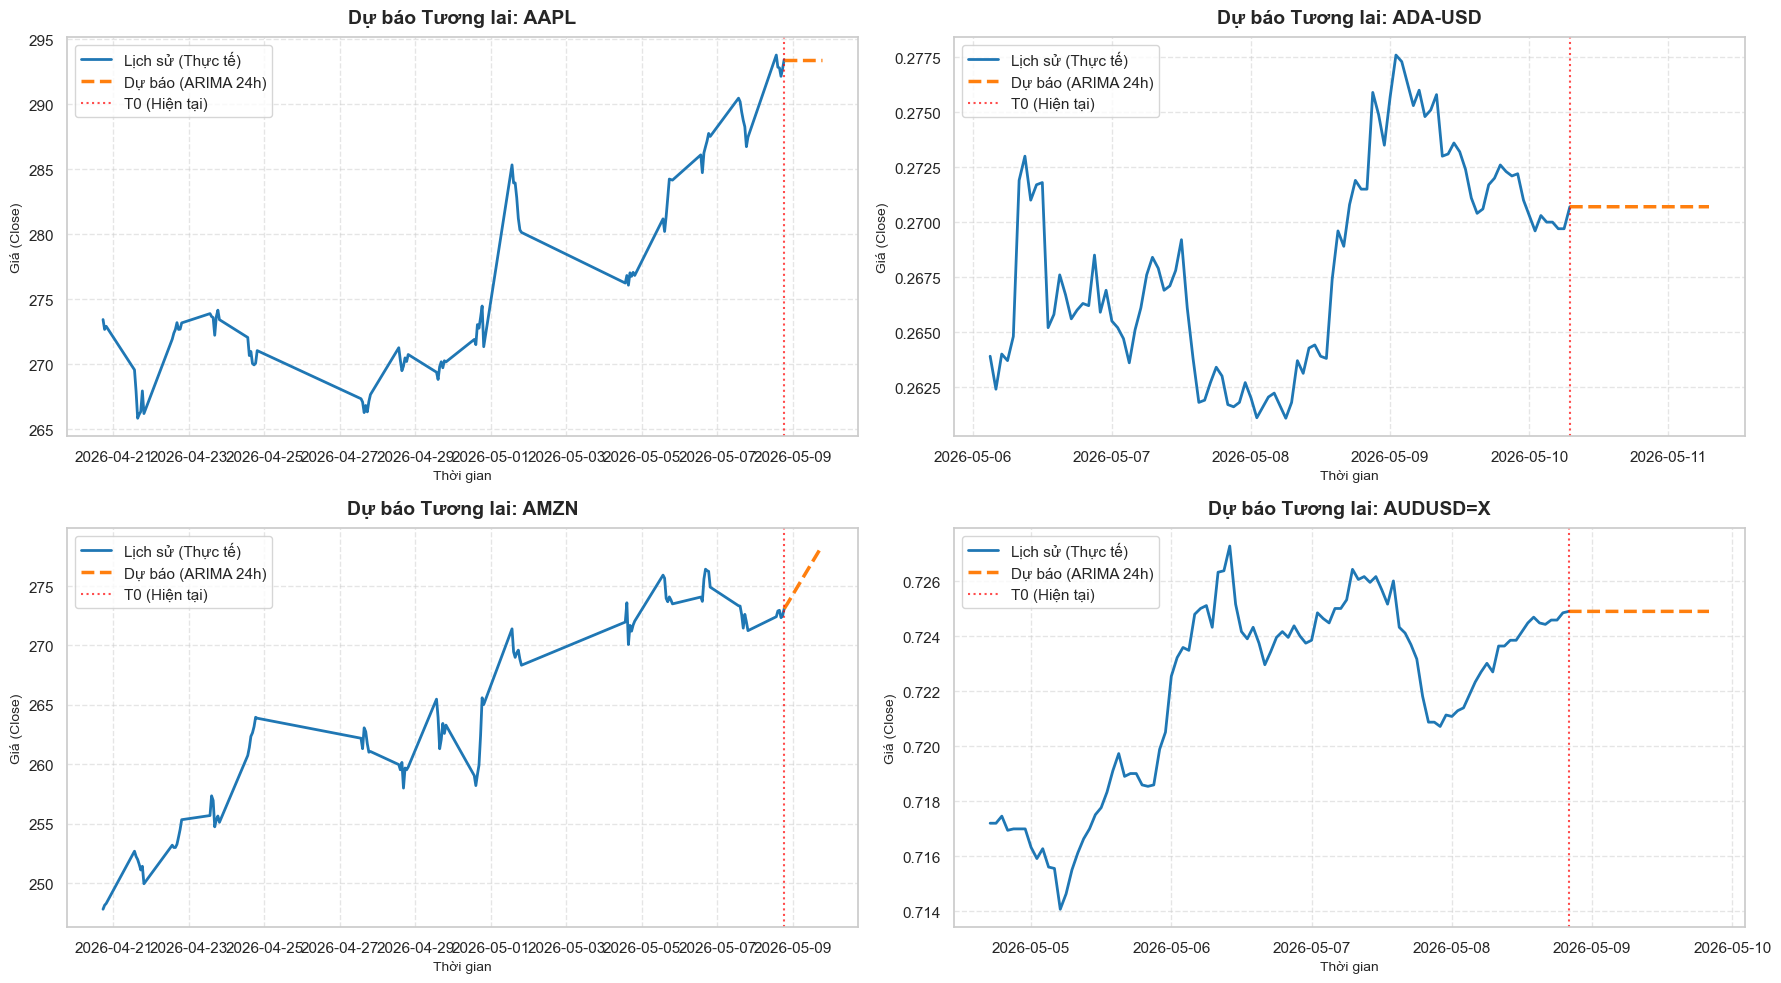

In [29]:
sample_symbols = df['symbol'].unique()[:4] 
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for i, sym in enumerate(sample_symbols):
    hist_data = df[df['symbol'] == sym].tail(100)
    pred_data = df_forecast[df_forecast['symbol'] == sym]
    axes[i].plot(hist_data['datetime'], hist_data['close'], 
                 label='Lịch sử (Thực tế)', color='#1f77b4', linewidth=2)
    
    combined_dates = [hist_data['datetime'].iloc[-1]] + list(pred_data['datetime'])
    combined_prices = [hist_data['close'].iloc[-1]] + list(pred_data['predicted_close'])
    
    axes[i].plot(combined_dates, combined_prices, 
                 label='Dự báo (ARIMA 24h)', color='#ff7f0e', linestyle='--', linewidth=2.5)
    
    axes[i].axvline(x=hist_data['datetime'].iloc[-1], color='red', linestyle=':', 
                    alpha=0.7, label='T0 (Hiện tại)')
    
    axes[i].set_title(f'Dự báo Tương lai: {sym}', fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel('Thời gian', fontsize=10)
    axes[i].set_ylabel('Giá (Close)', fontsize=10)
    axes[i].legend(loc='best')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### **Phân tích trực quan kết quả dự báo tương lai**

Quan sát kết quả dự báo **24 giờ tiếp theo** của 4 tài sản đại diện, có thể rút ra một số điểm đáng chú ý về hành vi của mô hình **ARIMA** trong môi trường thực tế:
##### **1. Hiện tượng “đường dự báo nằm ngang” (Random Walk Behavior)**

Với các tài sản như **Apple Inc.**, **Cardano** và **AUD/USD**, sau thời điểm T0, mô hình chủ yếu dự báo một đường gần như đi ngang quanh mức giá hiện tại.

**Giải thích:**

* Đây không phải lỗi mô hình
* Với các thị trường có tính hiệu quả cao, chuỗi giá thường mang đặc điểm **Random Walk**
* Khi đó, mô hình ARIMA tối ưu thường cho kết quả: *giá tương lai ≈ giá hiện tại*

→ Đường forecast nằm ngang cho thấy mô hình đang **ưu tiên sự thận trọng**, thay vì tạo ra biến động không có cơ sở thống kê.

##### **2. Khả năng bắt xu hướng ngắn hạn**

Khác với các tài sản trên, **Amazon.com, Inc.** cho thấy đường dự báo có độ dốc tăng khá rõ sau T0.

**Giải thích:**

* Mô hình phát hiện tín hiệu **trend/momentum** đủ mạnh trong dữ liệu lịch sử gần nhất
* Các thành phần **AR (Auto-Regressive)** được giữ lại thay vì triệt tiêu

→ Điều này cho thấy ARIMA không chỉ “đứng yên”, mà vẫn có khả năng bám theo xu hướng khi tín hiệu đủ rõ.

##### **Kết luận**

Mô hình **ARIMA baseline** cho thấy hành vi khá ổn định:

* Khi thị trường nhiễu hoặc ngẫu nhiên → dự báo **flatline**
* Khi xuất hiện xu hướng rõ → dự báo **theo momentum**
